# Preparando o Notebook e as ferramentas

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print('Bibliotecas carregadas com sucesso!')

# Carregando a base de dados
df = pd.read_csv('credit_risk_dataset.csv')

print('Arquivo csv carregado com sucesso!')

Bibliotecas carregadas com sucesso!
Arquivo csv carregado com sucesso!


In [6]:
# Verificando dimensões e os primeiros dados
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")
df.head()

Linhas: 32581, Colunas: 12


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
# Resumo estatístico
print(df.describe())

# Verificando valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

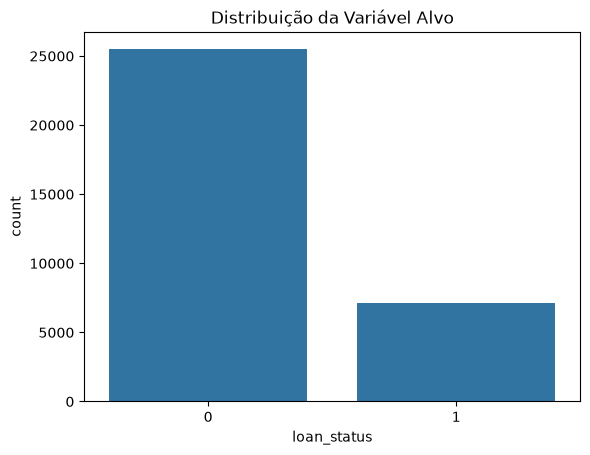

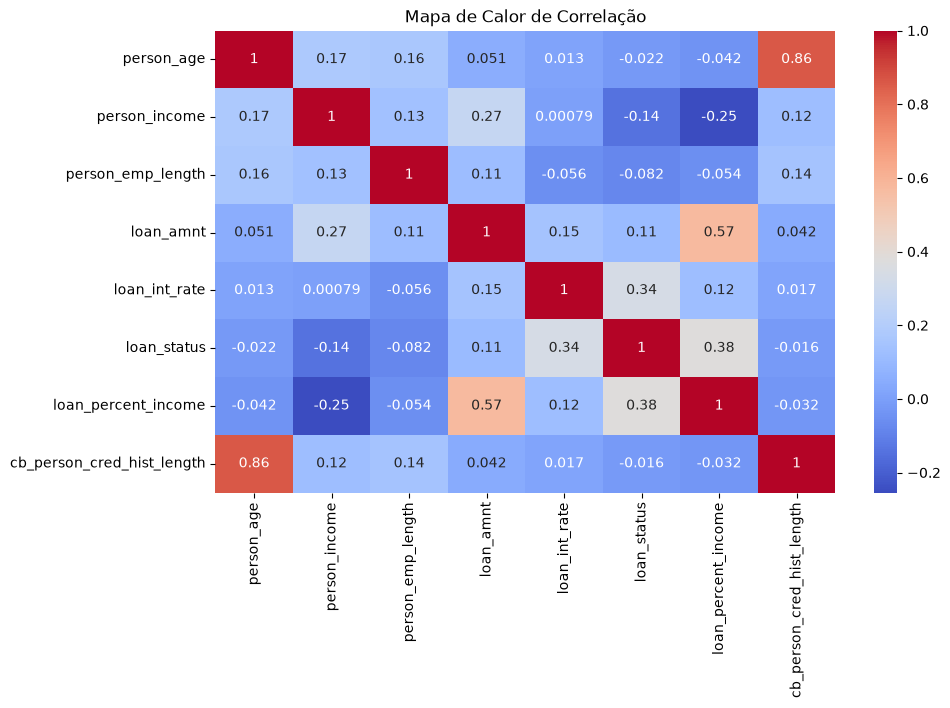

In [8]:
# 1. Distribuição do alvo (se o cliente é inadimplente ou não)
sns.countplot(x='loan_status', data=df)
plt.title('Distribuição da Variável Alvo')
plt.show()

# 2. Correlação (para ver como as colunas se relacionam)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlação')
plt.show()

## 1. Relatório de Análise Exploratória (EDA)

### 1.1 Análise Estatística e Estrutural
- **Volume:** A base analisada possui 32.581 registros.
- **Limpeza Necessária:** Identificamos nulos em `loan_int_rate` e `person_emp_length`. Também detectamos outliers na idade (144 anos) e tempo de emprego (123 anos), que serão tratados na fase de limpeza.

### 1.2 Insights Visuais
- **Distribuição da Variável Alvo:** O `countplot` revela um desbalanceamento na variável `loan_status`. A classe majoritária (0) domina, o que exigirá técnicas de reamostragem no treinamento para evitar um modelo enviesado.
- **Correlação:** O `heatmap` destaca correlações moderadas entre `loan_status` e variáveis como `loan_int_rate` (taxa de juros) e `loan_percent_income`. Isso indica que estas variáveis são preditores importantes para o nosso modelo.

### 1.3 Decisões para o Pipeline
1. **Limpeza:** Remover registros com dados impossíveis (outliers).
2. **Imputação:** Utilizar a mediana para tratar os nulos, dado que a distribuição não é perfeitamente normal.
3. **Engenharia:** Criar a coluna `comprometimento_renda` para aumentar o poder preditivo do modelo.

# Limpeza de Outliers e Duplicadas

In [3]:
# 1. Remover registros duplicados, se houver
df = df.drop_duplicates()

# 2. Remover Outliers (Filtros de lógica de negócio)
# Idade não pode ser 144, tempo de trabalho não pode ser 123
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] <= 60]

print(f"Linhas restantes: {df.shape[0]}")

Linhas restantes: 31522


# Tratando dados faltantes (Imputação)

In [4]:
# Preenchendo os nulos com a mediana
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

# Conferindo se ainda existem nulos
print("Total de valores nulos:", df.isnull().sum().sum())

Total de valores nulos: 0


Engenharia de Atributos

In [5]:
# Criando a nova coluna
df['comprometimento_renda'] = df['loan_amnt'] / df['person_income']

# Verificando se deu certo
print(df[['loan_amnt', 'person_income', 'comprometimento_renda']].head())

   loan_amnt  person_income  comprometimento_renda
1       1000           9600               0.104167
2       5500           9600               0.572917
3      35000          65500               0.534351
4      35000          54400               0.643382
5       2500           9900               0.252525


## 2. Tratamento e Limpeza (Data Prep)

### 2.1 Limpeza de Dados
* **Remoção de Outliers:** Identificamos idades de 144 anos e tempo de emprego de 123 anos, que são inconsistentes. Essas linhas foram removidas para garantir a qualidade do treinamento.
* **Duplicatas:** Removidas para evitar viés nos dados.

### 2.2 Tratamento de Nulos
* **Abordagem:** As variáveis `person_emp_length` e `loan_int_rate` continham valores nulos.
* **Justificativa:** Optamos pela **imputação pela mediana** em vez da exclusão das linhas, para não perder volume de dados (importante para o modelo KNN).

### 2.3 Engenharia de Atributos
* **Nova Variável:** Criamos a coluna `comprometimento_renda`, calculada pela divisão do montante do empréstimo pela renda anual, para normalizar o poder de pagamento do solicitante.

# Converter Texto em Números (Encoding)

In [ ]:
# Transformar variáveis categóricas em numéricas
# columns lista as colunas de texto que restaram no DataFrame
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file'], drop_first=True)

print(df.head())

   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
1          21           9600                5.0       1000          11.14   
2          25           9600                1.0       5500          12.87   
3          23          65500                4.0      35000          15.23   
4          24          54400                8.0      35000          14.27   
5          21           9900                2.0       2500           7.14   

   loan_status  loan_percent_income  cb_person_cred_hist_length  \
1            0                 0.10                           2   
2            1                 0.57                           3   
3            1                 0.53                           2   
4            1                 0.55                           4   
5            1                 0.25                           2   

   comprometimento_renda  person_home_ownership_OTHER  ...  \
1               0.104167                        False  ...   
2         